## Dataset Overview

In [12]:
# Basic libraries
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

# Cleaning and PCA
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

# File paths
TESTPATH = "../data/raw/claims_train.csv"
TRAINPATH = "../data/raw/claims_test.csv"

# Load the train dataset
df = pd.read_csv(TRAINPATH)

In [13]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 135603 entries, 0 to 135602
Data columns (total 12 columns):
 #   Column      Non-Null Count   Dtype  
---  ------      --------------   -----  
 0   IDpol       135603 non-null  int64  
 1   ClaimNb     135603 non-null  int64  
 2   Exposure    135603 non-null  float64
 3   Area        135603 non-null  object 
 4   VehPower    135603 non-null  int64  
 5   VehAge      135603 non-null  int64  
 6   DrivAge     135603 non-null  int64  
 7   BonusMalus  135603 non-null  int64  
 8   VehBrand    135603 non-null  object 
 9   VehGas      135603 non-null  object 
 10  Density     135603 non-null  int64  
 11  Region      135603 non-null  object 
dtypes: float64(1), int64(7), object(4)
memory usage: 12.4+ MB


The training dataset contains **542,410 records** and **13 variables**.

- **Numerical features:** `IDpol`, `ClaimNb`, `Exposure`, `VehPower`, `VehAge`, `DrivAge`, `BonusMalus`, and `Density`
- **Categorical features:** `Area`, `VehBrand`, `VehGas`, and `Region`
- The variable **`IDpol`** was removed, as it serves only as a unique identifier and holds no predictive value.
- **No missing values** were detected in any of the columns.


In [14]:
# Drop the IDpol column as it is not useful for analysis
df.drop("IDpol", axis=1, errors="ignore", inplace=True)

In [15]:
df.describe()

,ClaimNb,Exposure,VehPower,VehAge,DrivAge,BonusMalus,Density
count,135603.000000,135603.000000,135603.000000,135603.000000,135603.000000,135603.000000,135603.000000
mean,0.053745,0.528391,6.460034,7.038251,45.482954,59.761325,1777.407358
std,0.245373,0.364357,2.052504,5.687814,14.145517,15.626057,3931.192004
min,0.000000,0.002732,4.000000,0.000000,18.000000,50.000000,1.000000
25%,0.000000,0.170000,5.000000,2.000000,34.000000,50.000000,92.000000
50%,0.000000,0.490000,6.000000,6.000000,44.000000,50.000000,391.000000
75%,0.000000,0.990000,7.000000,11.000000,55.000000,64.000000,1622.000000
max,16.000000,1.900000,15.000000,100.000000,100.000000,190.000000,27000.000000


### Summary of Numerical Features

- **Claims (`ClaimNb`)**: highly skewed — the mean is 0.0531 but the max reaches 11, meaning most policyholders report zero claims
- **Time insured (`Exposure`):** ranges from 0.0027 to 2.01, with a median around 0.49 (roughly half a year of risk exposure on average)
- **Vehicle power (`VehPower`)**: averages 6.45, mostly between 4 and 7, but some vehicles go up to 15 (high-performance cars)
- **Vehicle age (`VehAge`)**: has a median of 6 years, but some vehicles reach 100 years
- **Driver age (`DrivAge`)**: centers around 45 years, ranging from 18 to 100
- **Bonus-Malus (`BonusMalus`)**: mostly sits at 50, with a few extreme outliers up to 230
- **Population Density (`Density`)**: very uneven — median 393 vs max 27000, suggesting large variability across regions (urban vs rural)

**Takeaway:**  
Most policyholders have **no claims**, **moderate vehicle power**, and **limited exposure**, which does indicate realistic insurance scenarios.

Since `ClaimNb` is a potential target variable (label), we examined its distribution and found a **strong imbalance** — 94.98% of policyholders reported zero claims, while only 5.02% had one or more.  
The distribution also revealed a few **extreme outliers**, with up to **11 claims** recorded for a single policy.

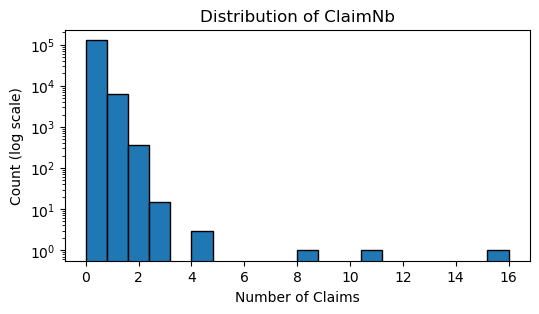

In [16]:
plt.figure(figsize=(6, 3))
plt.hist(df["ClaimNb"], bins=20, edgecolor="black")
plt.yscale("log")
plt.title("Distribution of ClaimNb")
plt.xlabel("Number of Claims")
plt.ylabel("Count (log scale)")
plt.show()

Moving onto the **Exposure** variable, as described earlier, it represents the **time at risk**, i.e. the duration (in years) a policy was active and exposed to potential claims.  
Most records fall within the expected range of **0–1 year**, corresponding to partial or full-year coverage.  

However, a few policies show **Exposure values greater than 1**, which likely indicate *errors in the dataset*.  

Given that our data represents historical records intended to show **the number of claims per year**, an exposure above one year would not make sense in this context. A record containing both the number of claims and an exposure longer than one year would only represent an **average annualized claim rate** rather than the actual observed count within a single year.  

To maintain consistency and ensure that all records reflect comparable one-year observation windows, we **cap the Exposure values at 1.0**.

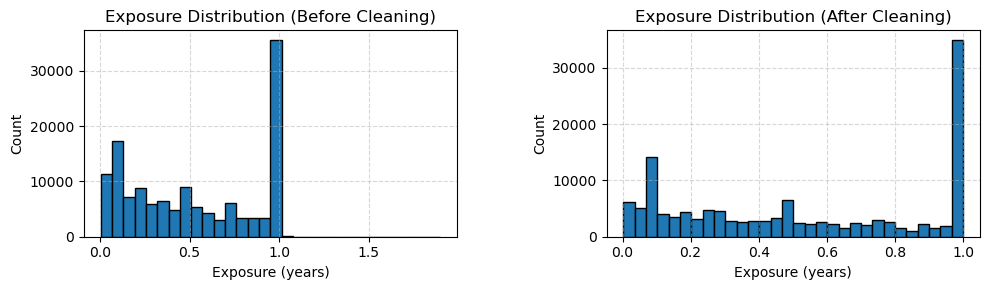

In [17]:
fig, axes = plt.subplots(1, 2, figsize=(10, 3))

# Before
axes[0].hist(df["Exposure"], bins=30, edgecolor="black")
axes[0].set_title("Exposure Distribution (Before Cleaning)")
axes[0].set_xlabel("Exposure (years)")
axes[0].set_ylabel("Count")
axes[0].grid(True, linestyle="--", alpha=0.5)

# Clean
cap_value = 1.0
df["Exposure"] = np.where(df["Exposure"] > cap_value, cap_value, df["Exposure"])

# After
axes[1].hist(df["Exposure"], bins=30, edgecolor="black", color="#1f77b4")
axes[1].set_title("Exposure Distribution (After Cleaning)")
axes[1].set_xlabel("Exposure (years)")
axes[1].set_ylabel("Count")
axes[1].grid(True, linestyle="--", alpha=0.5)

plt.tight_layout()
plt.subplots_adjust(wspace=0.4)
plt.show()

Later on we discovered that having 11 claims in a year is not as bad/rare as **2 claims within just 18 hours of exposure** (Exposure = 0.0027 years). This indicates that **exposure duration** plays a crucial role in interpreting claim counts.  


### Claims per Year Exposure (ClaimFrequency)

To make claim activity **comparable across different exposure durations**, we derived a new variable called **Exposure-Normalized Claim Rate**, defined as:

$$
\text{ClaimFrequency} = \frac{\text{ClaimNb}}{\text{Exposure}}
$$

This transformation ensures that claim intensity is measured on a **consistent scale**, regardless of how long each policy was active.

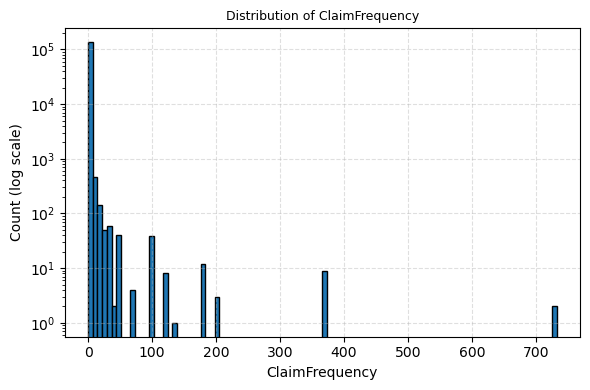

In [18]:
# Calculate ClaimFrequency
df["ClaimFrequency"] = df["ClaimNb"] / df["Exposure"]

# Drop the original columns
df.drop(["ClaimNb"], axis=1, errors="ignore", inplace=True)
df.drop(["Exposure"], axis=1, errors="ignore", inplace=True)

plt.figure(figsize=(6, 4))

plt.hist(df["ClaimFrequency"], bins=100, edgecolor="black")
plt.yscale("log")
plt.title("Distribution of ClaimFrequency", fontsize=9)
plt.xlabel("ClaimFrequency")
plt.ylabel("Count (log scale)")
plt.grid(True, linestyle="--", alpha=0.4)

plt.tight_layout()
plt.show()

### Choice of Target Variable

After careful consideration, we decided to use **ClaimFrequency** as our target variable for modeling.  

While the **ClaimFrequency** (defined as the number of claims per year of exposure) initially raised some concerns, it ultimately provided stronger modeling potential due to its **higher variance** and better ability to **differentiate claim behavior** across policyholders. 

However, this choice was made with a clear understanding of its trade-offs:  

- **Prediction context:**  
  The modeling objective is to estimate the expected claim activity for a new client. Since exposure is known at prediction time, ClaimFrequency allows the model to learn *intensity of claims* independent of contract duration.  
  The final number of claims can still be derived as:  

  $$
  \text{Predicted ClaimNb} = \text{Predicted ClaimFrequency} \times \text{Exposure}
  $$  

  This introduces an extra transformation step but improves comparability across clients with different exposure periods.  

- **Interpretation limitation:**  
  Although ClaimFrequency standardizes claim activity, it does not fully capture the **absolute business impact** — three short-term claims can be as costly as three long-term ones. Hence, while statistically fair, its practical interpretation requires context.  

- **Correlation consideration:**  
  Because Exposure appears in the denominator of ClaimFrequency, it is naturally correlated with the target. This can lead to *information leakage* if kept included as a variable.   

In summary, despite its potential complications, **ClaimFrequency** was chosen as the target due to its **higher variance** and better suitability for **variance-driven algorithms** (e.g., boosting), where richer target variability helps optimize performance during early training.

## Data Analysis and Cleaning for numarical variables

Now, we go through all numerical variables one by one checking for the distribution and outliers, starting with **VehAge**, which represents the age of the vehicle in years.  
From the distribution, it is clear that vehicles older than **around 25 years** are extremely rare and not representative of the general insured population.  

To prevent these extreme values from skewing the model, we applied a **quantile-based cap**. Specifically, we limited `VehAge` to the **99.5th percentile**, which corresponds to about **24 years**.

VehAge: capped above 24.00


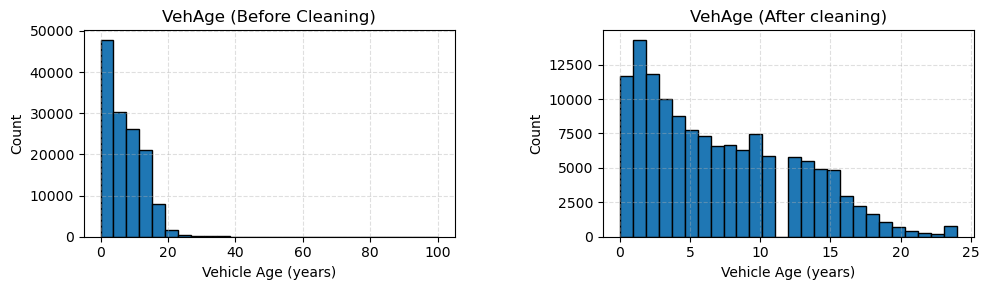

In [19]:
fig, axes = plt.subplots(1, 2, figsize=(10, 3))

# Before
axes[0].hist(df["VehAge"], bins=26, edgecolor="black")
axes[0].set_title("VehAge (Before Cleaning)")
axes[0].set_xlabel("Vehicle Age (years)")
axes[0].set_ylabel("Count")
axes[0].grid(True, linestyle="--", alpha=0.4)

# Clean
cap_value =  df["VehAge"].quantile(0.995)
print(f"VehAge: capped above {cap_value:.2f}")

df["VehAge"] = df["VehAge"].clip(upper=cap_value)

# After
axes[1].hist(df["VehAge"], bins=26, edgecolor="black", color="#1f77b4")
axes[1].set_title("VehAge (After cleaning)")
axes[1].set_xlabel("Vehicle Age (years)")
axes[1].set_ylabel("Count")
axes[1].grid(True, linestyle="--", alpha=0.4)

plt.tight_layout()
plt.subplots_adjust(wspace=0.4)
plt.show()

**DrivAge** represents the age of the driver, whose values mostly fall between **18 and 86.5 years**, consistent with legal and realistic limits for insured individuals.  

Extremely high ages are rare and may introduce noise into the model rather than providing meaningful predictive value.

To address this, we applied a **quantile-based upper cap** at the **99.5th percentile** (approximately **83 years**), limiting the influence of extreme cases.

DrivAge: capped above 82.00


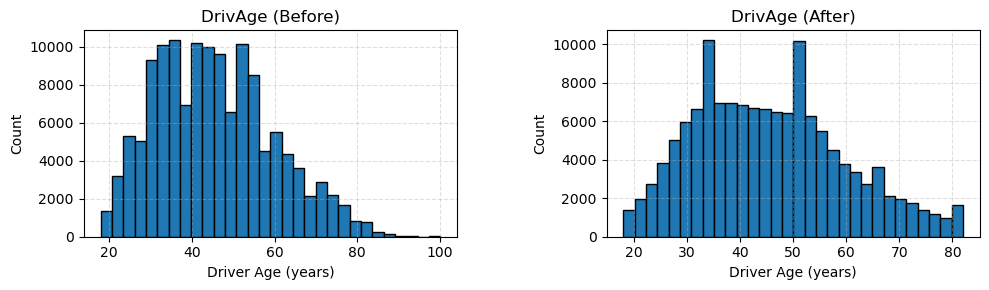

In [20]:
fig, axes = plt.subplots(1, 2, figsize=(10, 3))

# Before
axes[0].hist(df["DrivAge"], bins=30, edgecolor="black")
axes[0].set_title("DrivAge (Before)")
axes[0].set_xlabel("Driver Age (years)")
axes[0].set_ylabel("Count")
axes[0].grid(True, linestyle="--", alpha=0.4)

# Clean
cap_value = df["DrivAge"].quantile(0.995)
print(f"DrivAge: capped above {cap_value:.2f}")

df["DrivAge"] = df["DrivAge"].clip(upper=cap_value)

# After
axes[1].hist(df["DrivAge"], bins=30, edgecolor="black", color="#1f77b4")
axes[1].set_title("DrivAge (After)")
axes[1].set_xlabel("Driver Age (years)")
axes[1].set_ylabel("Count")
axes[1].grid(True, linestyle="--", alpha=0.4)

plt.tight_layout()
plt.subplots_adjust(wspace=0.4)
plt.show()

The **BonusMalus** variable represents the driver's penalty factor.  
Most policyholders have values around **50**, indicating a neutral risk profile, while higher numbers represent penalties due to previous claims.  

The distribution shows that **values above 118 are extremely rare** and would only distort the model — the same issues as discussed earlier may occur here as well.

In this scenario, we **cap BonusMalus at 118**, ensuring the variable remains within a realistic and interpretable range and in the meantime preventing extreme penalty values from dominating the model.

BonusMalus: capped above 118.00


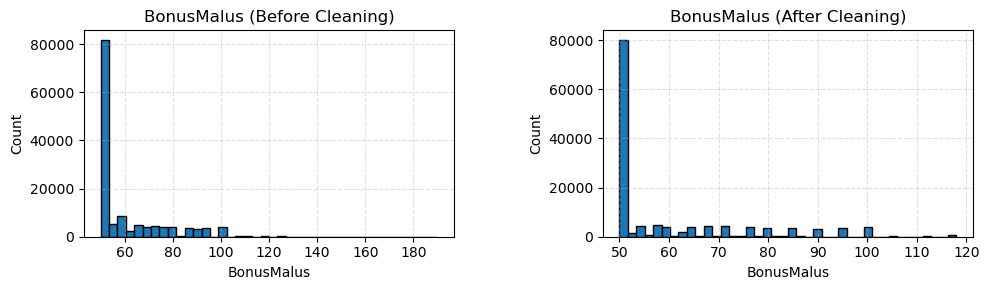

In [21]:
fig, axes = plt.subplots(1, 2, figsize=(10, 3))

# Before
axes[0].hist(df["BonusMalus"], bins=40, edgecolor="black")
axes[0].set_title("BonusMalus (Before Cleaning)")
axes[0].set_xlabel("BonusMalus")
axes[0].set_ylabel("Count")
axes[0].grid(True, linestyle="--", alpha=0.4)

# Clean
cap_value = df["BonusMalus"].quantile(0.995)
print(f"BonusMalus: capped above {cap_value:.2f}")

df["BonusMalus"] = df["BonusMalus"].clip(upper=cap_value)

# After
axes[1].hist(df["BonusMalus"], bins=40, edgecolor="black", color="#1f77b4")
axes[1].set_title("BonusMalus (After Cleaning)")
axes[1].set_xlabel("BonusMalus")
axes[1].set_ylabel("Count")
axes[1].grid(True, linestyle="--", alpha=0.4)

plt.tight_layout()
plt.subplots_adjust(wspace=0.4)
plt.show()

Lastly, we examine the **Density** variable, representing the population density of the policyholder’s region.  
The distribution is highly right-skewed — most policyholders live in low- to medium-density areas, while a few records correspond to extremely urban regions with densities exceeding **20,000 inhabitants/km²**.  

These high values are valid but heavily distort the scale of the variable.  
Instead of capping them, we apply a **logarithmic transformation** to reduce skewness while preserving the relative differences between rural and urban regions.  

The transformed variable, `Density`, provides a more balanced representation of regional density and will be used for further analysis and modeling.

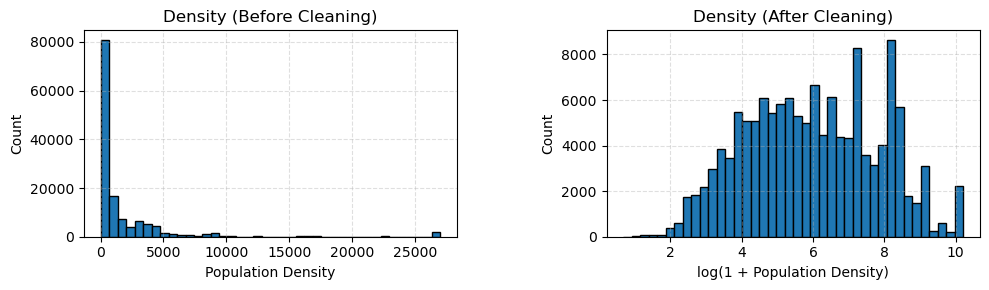

In [22]:
fig, axes = plt.subplots(1, 2, figsize=(10, 3))

# Before
axes[0].hist(df["Density"], bins=40, edgecolor="black")
axes[0].set_title("Density (Before Cleaning)")
axes[0].set_xlabel("Population Density")
axes[0].set_ylabel("Count")
axes[0].grid(True, linestyle="--", alpha=0.4)

# Clean
df["Density"] = np.log1p(df["Density"])

# After
axes[1].hist(df["Density"], bins=40, edgecolor="black", color="#1f77b4")
axes[1].set_title("Density (After Cleaning)")
axes[1].set_xlabel("log(1 + Population Density)")
axes[1].set_ylabel("Count")
axes[1].grid(True, linestyle="--", alpha=0.4)

plt.tight_layout()
plt.subplots_adjust(wspace=0.4)
plt.show()

## Data Analysis and Cleaning for cathegorical variables

Now, we go through all cathegorical variables one by one checking for the distribution and outliers, starting with **VehAge**, which represents the age of the vehicle in years.

=== Distribution of Categorical Variables ===
Found categorical columns: ['VehBrand', 'VehPower', 'VehGas', 'Region', 'Area']


/var/folders/ty/_y0hdfkn621_24n10_zyqlhm0000gn/T/ipykernel_1449/1490662010.py:20: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(y=col, data=df, order=order, palette="crest")


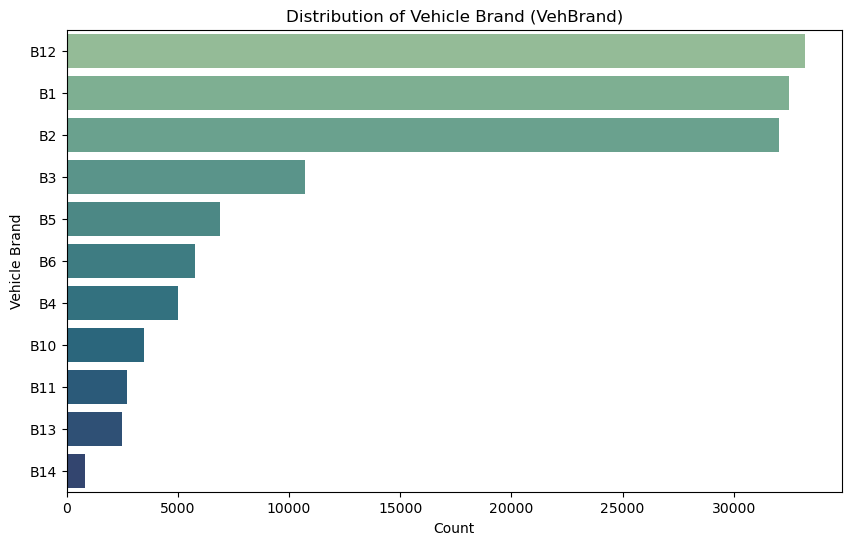

,Count,Percent
VehBrand,,
B12,33193,24.48
B1,32480,23.95
B2,32040,23.63
B3,10713,7.90
B5,6903,5.09
B6,5794,4.27
B4,4993,3.68
B10,3487,2.57
B11,2696,1.99


In [23]:
# =====================================================
# 10. Data Analysis for Categorical Variables
# =====================================================

print("=== Distribution of Categorical Variables ===")

# List of categorical variables
categorical_cols = [ "VehBrand", "VehPower", "VehGas", "Region", "Area"]
categorical_cols = [col for col in categorical_cols if col in df.columns]
print(f"Found categorical columns: {categorical_cols}")



# =====================================================
# VehBrand
# =====================================================
col = "VehBrand"
plt.figure(figsize=(10, 6))
order = df[col].value_counts().index
sns.countplot(y=col, data=df, order=order, palette="crest")
plt.title("Distribution of Vehicle Brand (VehBrand)")
plt.xlabel("Count")
plt.ylabel("Vehicle Brand")
plt.show()

display(
    df[col].value_counts()
    .to_frame(name="Count")
    .assign(Percent=lambda x: (x["Count"] / len(df) * 100).round(2))
    .head(15)
)

## VehBrand — Vehicle Brand

**Description:**  
Identifies the manufacturer or brand of the vehicle.

**Observation:**  
The dataset contains multiple brands, with **B12**, **B1**, and **B2** dominating the distribution.  
A few brands such as **B13** and **B14** appear very infrequently, indicating high imbalance.

**Evaluation:**  
- Distribution is highly skewed — a few brands dominate.  
- Consider grouping rare brands under an `"Other"` category.  
- Reflects socioeconomic or market segment differences between policyholders.

---


/var/folders/ty/_y0hdfkn621_24n10_zyqlhm0000gn/T/ipykernel_1449/1346663507.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=col, data=df, palette="magma")


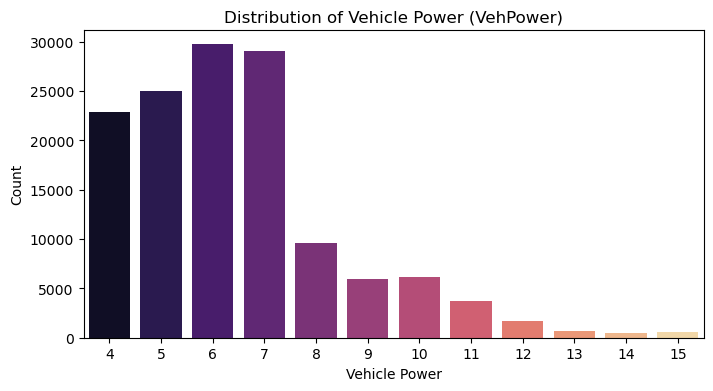

,Count,Percent
VehPower,,
4,22936,16.91
5,24980,18.42
6,29746,21.94
7,29061,21.43
8,9587,7.07
9,6005,4.43
10,6195,4.57
11,3700,2.73
12,1699,1.25


In [24]:

# =====================================================
# VehPower
# =====================================================
col = "VehPower"
plt.figure(figsize=(8, 4))
sns.countplot(x=col, data=df, palette="magma")
plt.title("Distribution of Vehicle Power (VehPower)")
plt.xlabel("Vehicle Power")
plt.ylabel("Count")
plt.show()

display(
    df[col].value_counts()
    .sort_index()
    .to_frame(name="Count")
    .assign(Percent=lambda x: (x["Count"] / len(df) * 100).round(2))
)

## VehPower — Vehicle Power

**Description:**  
Indicates the vehicle’s horsepower or power category.

**Observation:**  
The distribution peaks around **6–7**, meaning most insured vehicles fall into a mid-power range.  
Very few vehicles exceed power level 10, creating a right-skewed shape.

**Evaluation:**  
- The feature is ordinal rather than purely categorical.  
- High-power vehicles may represent riskier or luxury categories.  
- Rare high values might require grouping or capping during modeling.

---

/var/folders/ty/_y0hdfkn621_24n10_zyqlhm0000gn/T/ipykernel_1449/1659843519.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=col, data=df, palette="Set2")


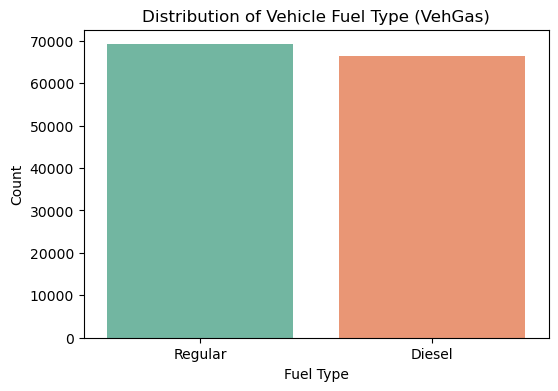

,Count,Percent
VehGas,,
Regular,69154,51.0
Diesel,66449,49.0


In [25]:

# =====================================================
# VehGas
# =====================================================
col = "VehGas"
plt.figure(figsize=(6, 4))
sns.countplot(x=col, data=df, palette="Set2")
plt.title("Distribution of Vehicle Fuel Type (VehGas)")
plt.xlabel("Fuel Type")
plt.ylabel("Count")
plt.show()

display(
    df[col].value_counts()
    .to_frame(name="Count")
    .assign(Percent=lambda x: (x["Count"] / len(df) * 100).round(2))
)


## VehGas — Fuel Type

**Description:**  
Represents the type of fuel the vehicle uses (e.g., Regular, Diesel).

**Observation:**  
The dataset shows two almost equally common categories: **Regular** and **Diesel**.  
No alternative fuels like hybrid or electric appear in this dataset.

**Evaluation:**  
- Balanced distribution — no need for reweighting.  
- Could interact with `VehPower` or `VehAge` (e.g., newer diesels vs older petrols).  
- Straightforward to encode as dummy variables.

---

/var/folders/ty/_y0hdfkn621_24n10_zyqlhm0000gn/T/ipykernel_1449/1644124405.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(y=col, data=df, order=order, palette="Blues")


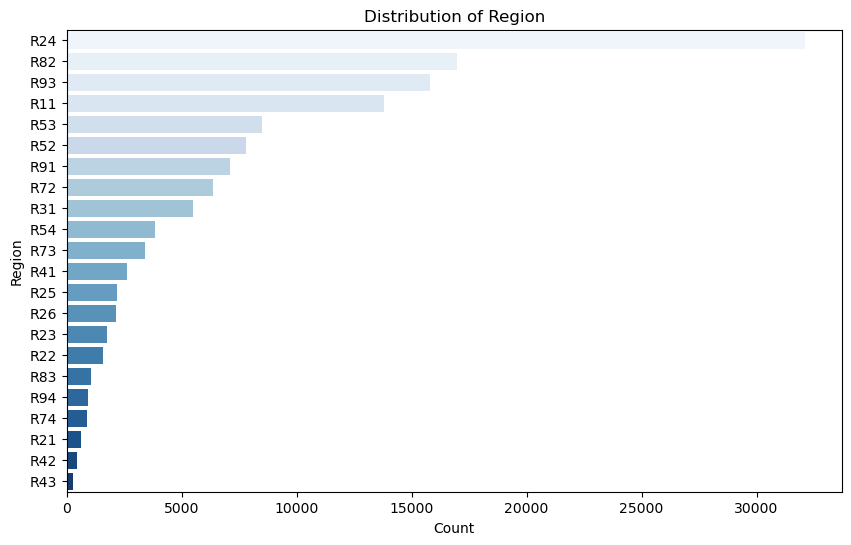

,Count,Percent
Region,,
R24,32099,23.67
R82,16980,12.52
R93,15798,11.65
R11,13807,10.18
R53,8479,6.25
R52,7809,5.76
R91,7083,5.22
R72,6364,4.69
R31,5472,4.04


In [26]:

# =====================================================
# Region
# =====================================================
col = "Region"
plt.figure(figsize=(10, 6))
order = df[col].value_counts().index
sns.countplot(y=col, data=df, order=order, palette="Blues")
plt.title("Distribution of Region")
plt.xlabel("Count")
plt.ylabel("Region")
plt.show()

display(
    df[col].value_counts()
    .to_frame(name="Count")
    .assign(Percent=lambda x: (x["Count"] / len(df) * 100).round(2))
    .head(15)
)


## Region — Geographic Region

**Description:**  
Denotes the geographic region of the policyholder or vehicle registration.

**Observation:**  
Regions such as **R24**, **R82**, and **R93** dominate the dataset, while many others have low representation.  
This shows a heavy regional imbalance, likely linked to population density or coverage.

**Evaluation:**  
- Strong imbalance may bias model training.  
- Rare regions could be merged or grouped by claim frequency.  
- Region can capture location-based risk differences (weather, traffic, etc.).

---

/var/folders/ty/_y0hdfkn621_24n10_zyqlhm0000gn/T/ipykernel_1449/1395233528.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=col, data=df, palette="coolwarm")


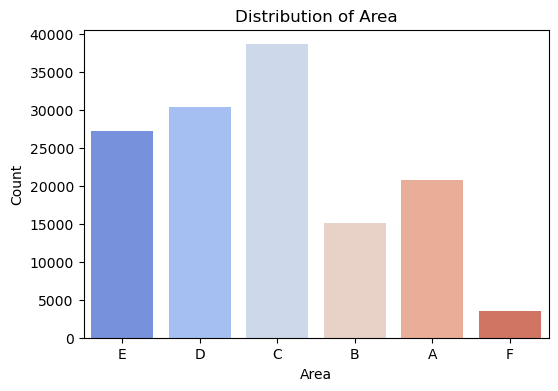

,Count,Percent
Area,,
C,38593,28.46
D,30361,22.39
E,27256,20.10
A,20807,15.34
B,15036,11.09
F,3550,2.62


In [27]:

# =====================================================
# Area
# =====================================================
col = "Area"
plt.figure(figsize=(6, 4))
sns.countplot(x=col, data=df, palette="coolwarm")
plt.title("Distribution of Area")
plt.xlabel("Area")
plt.ylabel("Count")
plt.show()

display(
    df[col].value_counts()
    .to_frame(name="Count")
    .assign(Percent=lambda x: (x["Count"] / len(df) * 100).round(2))
)


## Area — Area Type

**Description:**  
Categorical variable indicating the type of area (e.g., urban vs rural).

**Observation:**  
Categories **A–F** appear in varying proportions.  
**C** is the most frequent, while **F** is least common — but all classes are present in fair numbers.

**Evaluation:**  
- Balanced enough to retain all classes.  
- Likely correlates with claim rates — urban vs rural dynamics.  
- Safe for direct one-hot encoding.

---